In [6]:
import pandas as pd
import numpy as np

# 1. Cargar los datos crudos locales
df = pd.read_csv('../data/raw/historical_results.csv')

# 2. Limpieza inicial básica
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 3. Exploración rápida
print(f"Total de partidos analizados: {len(df)}")
print(f"Rango de fechas: {df['date'].min().date()} a {df['date'].max().date()}")

df

Total de partidos analizados: 25268
Rango de fechas: 2000-01-04 a 2026-06-27


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,False
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,True
...,...,...,...,...,...,...,...,...,...
25263,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
25264,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
25265,2026-06-27,Algeria,Austria,NaN,NaN,FIFA World Cup,Kansas City,United States,True
25266,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25268 entries, 0 to 25267
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        25268 non-null  datetime64[us]
 1   home_team   25268 non-null  str           
 2   away_team   25268 non-null  str           
 3   home_score  25196 non-null  float64       
 4   away_score  25196 non-null  float64       
 5   tournament  25268 non-null  str           
 6   city        25268 non-null  str           
 7   country     25268 non-null  str           
 8   neutral     25268 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(5)
memory usage: 1.6 MB


In [9]:
# 1. Eliminamos las filas donde falten los goles
df = df.dropna(subset=['home_score', 'away_score'])
print(f"Partidos limpios y listos: {len(df)}")

df.info()

Partidos limpios y listos: 25196
<class 'pandas.DataFrame'>
RangeIndex: 25196 entries, 0 to 25195
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        25196 non-null  datetime64[us]
 1   home_team   25196 non-null  str           
 2   away_team   25196 non-null  str           
 3   home_score  25196 non-null  float64       
 4   away_score  25196 non-null  float64       
 5   tournament  25196 non-null  str           
 6   city        25196 non-null  str           
 7   country     25196 non-null  str           
 8   neutral     25196 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(5)
memory usage: 1.6 MB


In [13]:
import numpy as np

# Creamos las condiciones basadas en los goles
condiciones = [
    df['home_score'] > df['away_score'],  # Victoria del equipo local
    df['home_score'] < df['away_score']   # Victoria del equipo visitante
]

# Definimos las clases a predecir
resultados = ['HW', 'AW']

# Aplicamos la lógica: si no es HW ni AW, por defecto es Empate ('D')
df['target'] = np.select(condiciones, resultados, default='D')

# Revisamos cómo quedó nuestro dataset listo
print("Distribución de nuestro Target:")
print(df['target'].value_counts(normalize=True) * 100)

df.head()

Distribución de nuestro Target:
target
HW    48.098905
AW    28.595809
D     23.305287
Name: proportion, dtype: float64


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,target
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False,HW
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False,HW
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False,D
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,False,D
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,True,D


/tmp/ipykernel_45838/1832374637.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axis[0, 0], x=top_home.values, y=top_home.index, palette='Blues_r')
/tmp/ipykernel_45838/1832374637.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axis[0, 1], x=top_away.values, y=top_away.index, palette='Oranges_r')
/tmp/ipykernel_45838/1832374637.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axis[1, 0], x=top_tournaments.values, y=top_tournaments.index, palette='Greens_r')
/tmp/ipykernel_45838/1832374637.py:26: FutureWarning: 

Passin

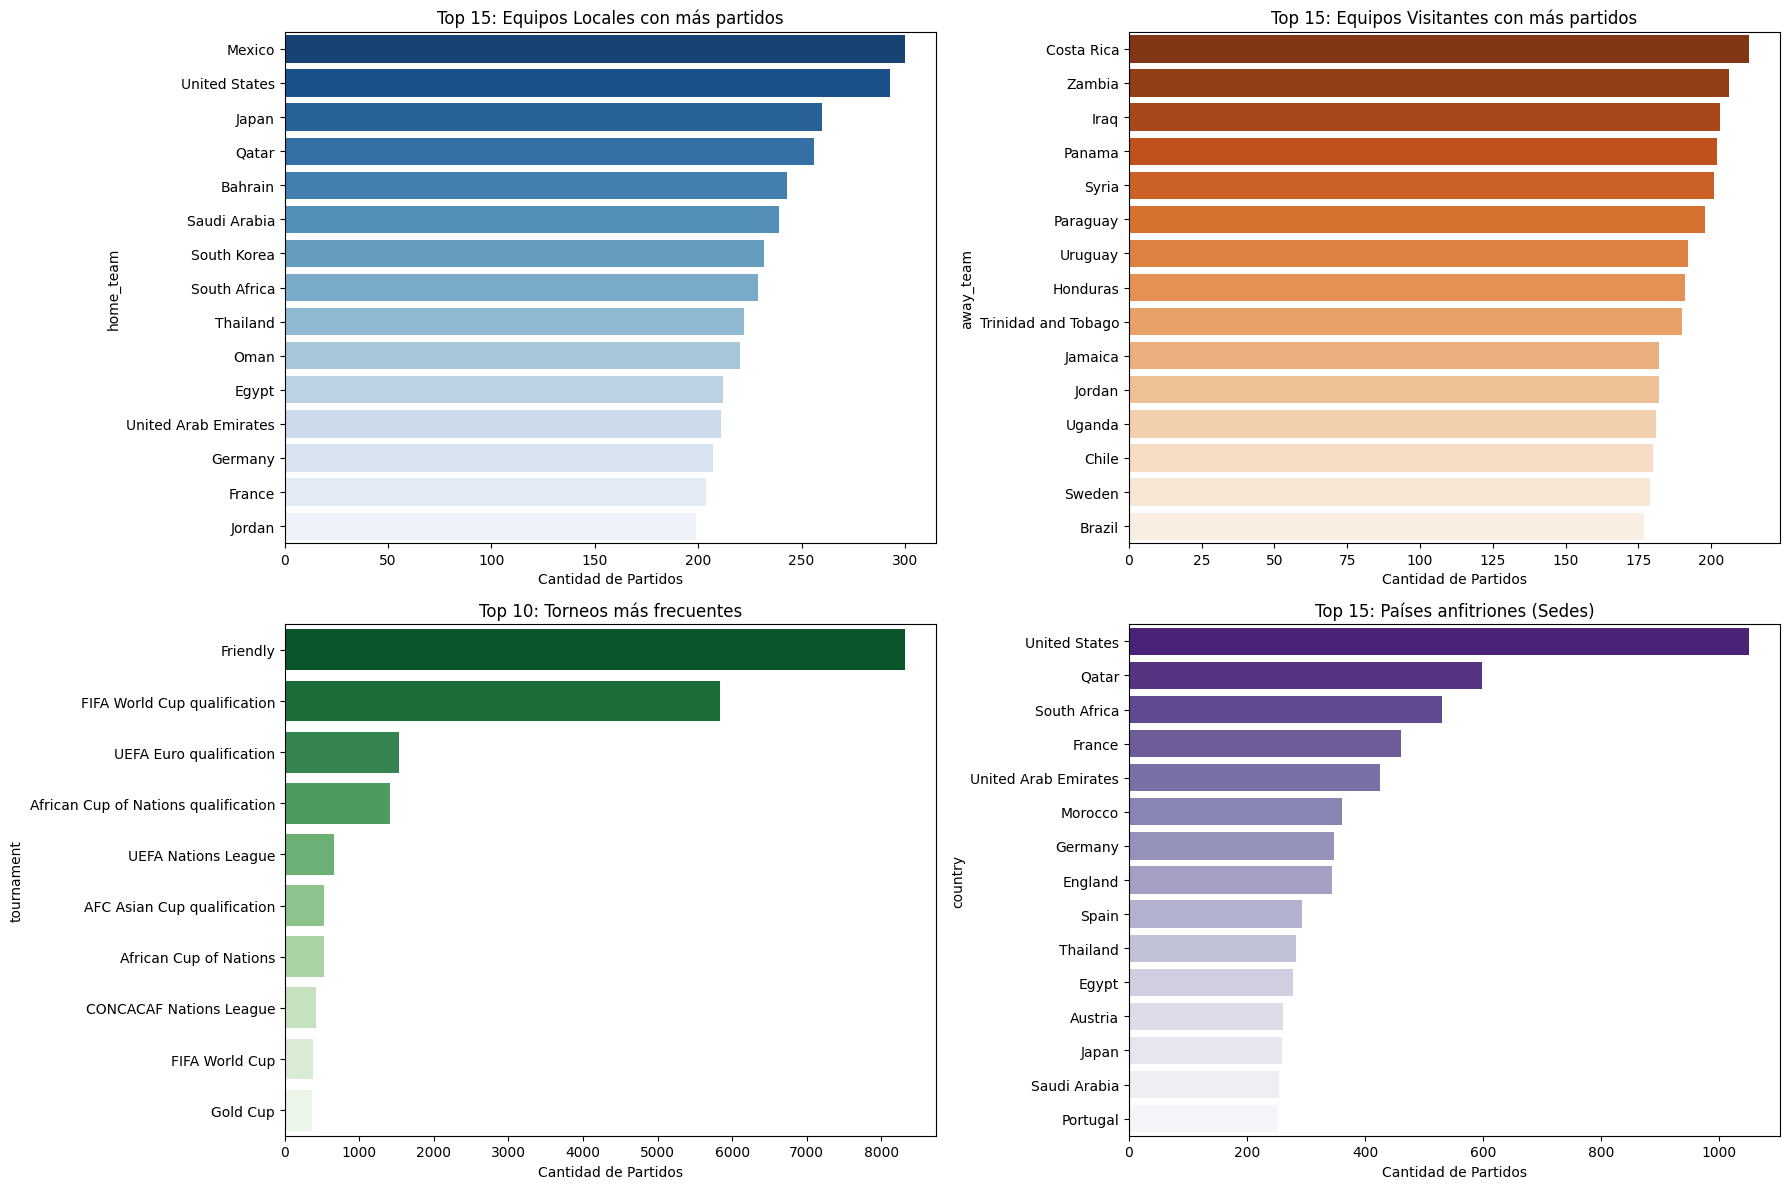

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aumentamos un poco el alto de la figura para que respiren los datos
fig, axis = plt.subplots(2, 2, figsize=(18, 12))

# 1. Filtramos el Top 15 de cada categoría para mantener la legibilidad
top_home = df['home_team'].value_counts().head(15)
top_away = df['away_team'].value_counts().head(15)
top_tournaments = df['tournament'].value_counts().head(10)
top_countries = df['country'].value_counts().head(15)

# 2. Usamos barplot con orientación horizontal (y=categoría, x=valores)
sns.barplot(ax=axis[0, 0], x=top_home.values, y=top_home.index, palette='Blues_r')
axis[0, 0].set_title('Top 15: Equipos Locales con más partidos')
axis[0, 0].set_xlabel('Cantidad de Partidos')

sns.barplot(ax=axis[0, 1], x=top_away.values, y=top_away.index, palette='Oranges_r')
axis[0, 1].set_title('Top 15: Equipos Visitantes con más partidos')
axis[0, 1].set_xlabel('Cantidad de Partidos')

sns.barplot(ax=axis[1, 0], x=top_tournaments.values, y=top_tournaments.index, palette='Greens_r')
axis[1, 0].set_title('Top 10: Torneos más frecuentes')
axis[1, 0].set_xlabel('Cantidad de Partidos')

sns.barplot(ax=axis[1, 1], x=top_countries.values, y=top_countries.index, palette='Purples_r')
axis[1, 1].set_title('Top 15: Países anfitriones (Sedes)')
axis[1, 1].set_xlabel('Cantidad de Partidos')

# Ajustamos el layout
plt.tight_layout()
plt.show()

/tmp/ipykernel_45838/3799432914.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axis[0], data=df, x='target', order=['HW', 'D', 'AW'], palette=['#2ca02c', '#7f7f7f', '#d62728'])
/tmp/ipykernel_45838/3799432914.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axis[1], data=df, x='neutral', palette='Set2')


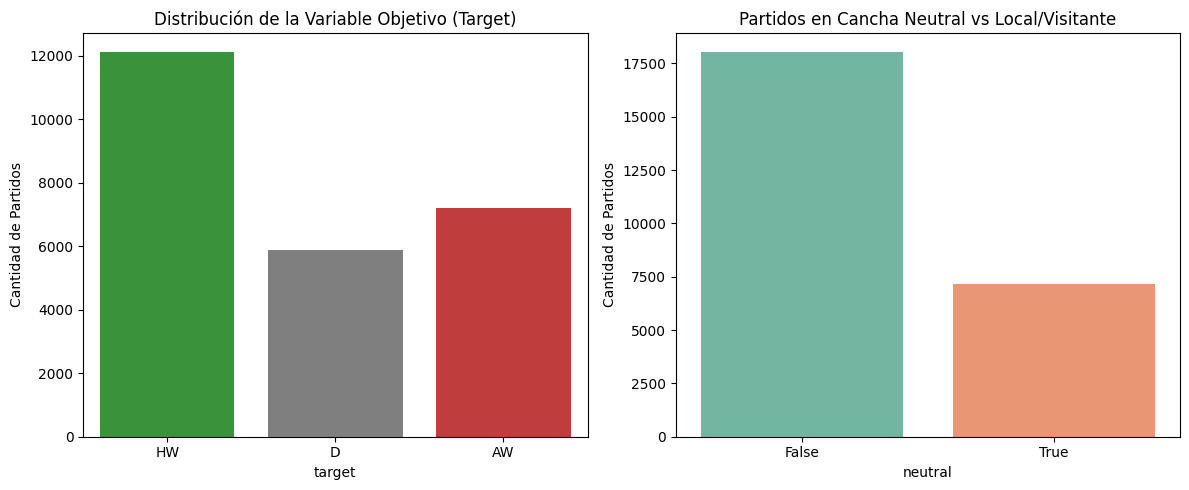

In [17]:
fig, axis = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Distribución del Target (Balance de clases)
sns.countplot(ax=axis[0], data=df, x='target', order=['HW', 'D', 'AW'], palette=['#2ca02c', '#7f7f7f', '#d62728'])
axis[0].set_title('Distribución de la Variable Objetivo (Target)')
axis[0].set_ylabel('Cantidad de Partidos')

# Gráfico 2: Proporción de Partidos en Cancha Neutral
sns.countplot(ax=axis[1], data=df, x='neutral', palette='Set2')
axis[1].set_title('Partidos en Cancha Neutral vs Local/Visitante')
axis[1].set_ylabel('Cantidad de Partidos')

plt.tight_layout()
plt.show()

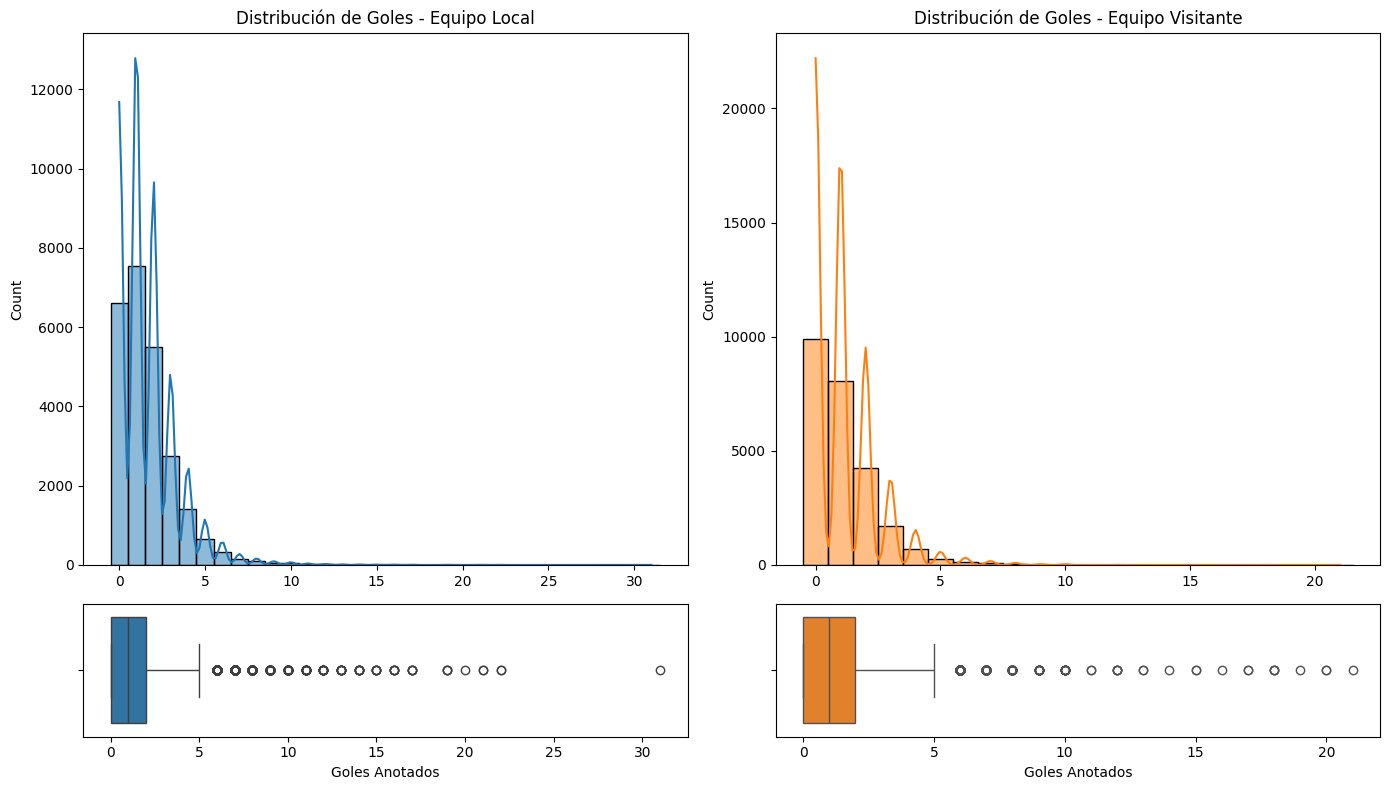

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos una cuadrícula de 2 filas por 2 columnas.
# El truco: 'height_ratios' hace que la fila de arriba (histogramas) sea 4 veces más alta que la de abajo (boxplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), gridspec_kw={'height_ratios': [4, 1]})

# Columna Izquierda: Goles del Equipo Local (home_score)
sns.histplot(ax=axes[0, 0], data=df, x='home_score', discrete=True, kde=True, color='#1f77b4')
axes[0, 0].set_title('Distribución de Goles - Equipo Local')
axes[0, 0].set_xlabel('') # Ocultamos el texto del eje X aquí para que no se repita con el boxplot

sns.boxplot(ax=axes[1, 0], data=df, x='home_score', color='#1f77b4')
axes[1, 0].set_xlabel('Goles Anotados')

# Columna Derecha: Goles del Equipo Visitante (away_score)
sns.histplot(ax=axes[0, 1], data=df, x='away_score', discrete=True, kde=True, color='#ff7f0e')
axes[0, 1].set_title('Distribución de Goles - Equipo Visitante')
axes[0, 1].set_xlabel('')

sns.boxplot(ax=axes[1, 1], data=df, x='away_score', color='#ff7f0e')
axes[1, 1].set_xlabel('Goles Anotados')

# Ajustamos el espaciado para que quede perfecto
plt.tight_layout()
plt.show()